In [1]:
from tensorflow import keras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_addons as tfa

np.random.seed(123)

In [2]:
def readucr(filename):
    data = np.loadtxt(filename, delimiter="\t")
    y = data[:, 0]
    x = data[:, 1:]
    return x, y.astype(int)

x_train, y_train = readucr("FordA_TRAIN.tsv")
x_test, y_test = readucr("FordA_TEST.tsv")

In [3]:
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

print(x_train.shape)

(3601, 500, 1)


In [4]:
y_train[y_train==-1] = 0
y_test[y_test==-1] = 0

In [5]:
print(y_train[:10])

[0 1 0 0 0 1 1 1 1 1]


In [6]:
idx = np.random.permutation(len(x_train))
x_train = x_train[idx]
y_train = y_train[idx]

In [7]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(32)
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

## Build a model

In [8]:
input_layer = keras.layers.Input((500, 1))

x = keras.layers.Conv1D(filters=64, kernel_size=3, padding="same")(input_layer)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.ReLU()(x)

x = keras.layers.Conv1D(filters=64, kernel_size=3, padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.ReLU()(x)

x = keras.layers.Conv1D(filters=64, kernel_size=3, padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.ReLU()(x)

x = keras.layers.GlobalAveragePooling1D()(x)
x = keras.layers.Dense(1, activation="sigmoid")(x)

model = keras.models.Model(inputs=input_layer, outputs=x)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 500, 1)]          0         
                                                                 
 conv1d (Conv1D)             (None, 500, 64)           256       
                                                                 
 batch_normalization (BatchN  (None, 500, 64)          256       
 ormalization)                                                   
                                                                 
 re_lu (ReLU)                (None, 500, 64)           0         
                                                                 
 conv1d_1 (Conv1D)           (None, 500, 64)           12352     
                                                                 
 batch_normalization_1 (Batc  (None, 500, 64)          256       
 hNormalization)                                             

## Train the model

In [9]:
epochs = 150
batch_size = 64

loss_func = tfa.losses.SigmoidFocalCrossEntropy(alpha=0.5, gamma=1.0)
model.compile(optimizer="adam",
              loss=loss_func,
              metrics=["accuracy"])
history = model.fit(train_ds,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(x_test, y_test),
                    verbose=2)

Epoch 1/150
113/113 - 27s - loss: 0.1331 - accuracy: 0.7104 - val_loss: 0.1929 - val_accuracy: 0.4841 - 27s/epoch - 241ms/step
Epoch 2/150
113/113 - 18s - loss: 0.1119 - accuracy: 0.7748 - val_loss: 0.1876 - val_accuracy: 0.4841 - 18s/epoch - 157ms/step
Epoch 3/150
113/113 - 18s - loss: 0.1058 - accuracy: 0.7917 - val_loss: 0.1817 - val_accuracy: 0.5273 - 18s/epoch - 158ms/step
Epoch 4/150
113/113 - 18s - loss: 0.1027 - accuracy: 0.8003 - val_loss: 0.1585 - val_accuracy: 0.6409 - 18s/epoch - 158ms/step
Epoch 5/150
113/113 - 18s - loss: 0.1004 - accuracy: 0.8073 - val_loss: 0.1247 - val_accuracy: 0.7697 - 18s/epoch - 157ms/step
Epoch 6/150
113/113 - 18s - loss: 0.0988 - accuracy: 0.8114 - val_loss: 0.1089 - val_accuracy: 0.7742 - 18s/epoch - 156ms/step
Epoch 7/150
113/113 - 18s - loss: 0.0964 - accuracy: 0.8170 - val_loss: 0.1259 - val_accuracy: 0.7197 - 18s/epoch - 158ms/step
Epoch 8/150
113/113 - 18s - loss: 0.0940 - accuracy: 0.8223 - val_loss: 0.1519 - val_accuracy: 0.6758 - 18s/epo

113/113 - 18s - loss: 0.0293 - accuracy: 0.9608 - val_loss: 0.0413 - val_accuracy: 0.9341 - 18s/epoch - 156ms/step
Epoch 66/150
113/113 - 18s - loss: 0.0270 - accuracy: 0.9636 - val_loss: 0.0301 - val_accuracy: 0.9629 - 18s/epoch - 158ms/step
Epoch 67/150
113/113 - 18s - loss: 0.0280 - accuracy: 0.9622 - val_loss: 0.0731 - val_accuracy: 0.8614 - 18s/epoch - 157ms/step
Epoch 68/150
113/113 - 18s - loss: 0.0274 - accuracy: 0.9645 - val_loss: 0.0316 - val_accuracy: 0.9545 - 18s/epoch - 158ms/step
Epoch 69/150
113/113 - 18s - loss: 0.0270 - accuracy: 0.9631 - val_loss: 0.4318 - val_accuracy: 0.6894 - 18s/epoch - 157ms/step
Epoch 70/150
113/113 - 18s - loss: 0.0278 - accuracy: 0.9631 - val_loss: 0.0382 - val_accuracy: 0.9439 - 18s/epoch - 157ms/step
Epoch 71/150
113/113 - 18s - loss: 0.0282 - accuracy: 0.9628 - val_loss: 0.0723 - val_accuracy: 0.8659 - 18s/epoch - 157ms/step
Epoch 72/150
113/113 - 18s - loss: 0.0268 - accuracy: 0.9653 - val_loss: 0.0445 - val_accuracy: 0.9197 - 18s/epoch - 

Epoch 129/150
113/113 - 18s - loss: 0.0213 - accuracy: 0.9708 - val_loss: 0.0440 - val_accuracy: 0.9379 - 18s/epoch - 156ms/step
Epoch 130/150
113/113 - 18s - loss: 0.0202 - accuracy: 0.9717 - val_loss: 0.0746 - val_accuracy: 0.8924 - 18s/epoch - 158ms/step
Epoch 131/150
113/113 - 18s - loss: 0.0203 - accuracy: 0.9722 - val_loss: 0.9139 - val_accuracy: 0.6848 - 18s/epoch - 155ms/step
Epoch 132/150
113/113 - 18s - loss: 0.0213 - accuracy: 0.9703 - val_loss: 0.0432 - val_accuracy: 0.9280 - 18s/epoch - 157ms/step
Epoch 133/150
113/113 - 18s - loss: 0.0211 - accuracy: 0.9686 - val_loss: 0.1619 - val_accuracy: 0.7371 - 18s/epoch - 159ms/step
Epoch 134/150
113/113 - 18s - loss: 0.0202 - accuracy: 0.9722 - val_loss: 0.0397 - val_accuracy: 0.9379 - 18s/epoch - 158ms/step
Epoch 135/150
113/113 - 18s - loss: 0.0204 - accuracy: 0.9720 - val_loss: 0.0937 - val_accuracy: 0.8712 - 18s/epoch - 158ms/step
Epoch 136/150
113/113 - 18s - loss: 0.0205 - accuracy: 0.9700 - val_loss: 0.3183 - val_accuracy: 

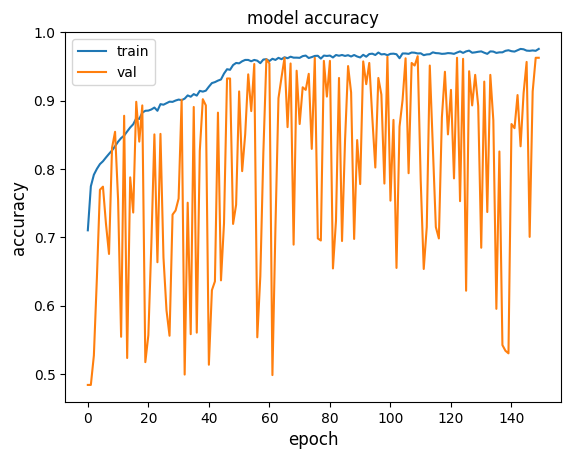

In [10]:
metric = "accuracy"
plt.figure()
plt.plot(history.history[metric])
plt.plot(history.history["val_" + metric])
plt.title("model " + metric)
plt.ylabel(metric, fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.show()
plt.close()